# Week 12: Dimensionality Reduction

**Goal:** Implement PCA from scratch.  Apply it for feature compression and visualization.  Re-run classifiers on PCA-reduced features and compare with full-feature results.

**Deliverable:** `minilearn/decomposition.py` (PCA complete) + this notebook.

---
## Checklist
- [ ] `PCA` in MiniLearn — eigendecomposition of covariance matrix
- [ ] Explained variance plot (scree plot)
- [ ] Choose n_components capturing ≥95% variance
- [ ] Re-run all classifiers on PCA features — compare to full-feature accuracy
- [ ] 2D scatter (PCA) colored by emotion
- [ ] Optional: t-SNE, UMAP

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

from minilearn.decomposition import PCA
from minilearn.metrics import accuracy, f1_score

from sklearn.decomposition import PCA as SklearnPCA
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

OUTPUT_DIR = 'C:\\Users\\Grana\\Documents\\GitHub\\Project_CSE432_MG\\Project_CSE432-532\\SER_Project\\output'

EMOTION_MAP = {
    1: 'neutral', 2: 'calm',    3: 'happy',    4: 'sad',
    5: 'angry',   6: 'fearful', 7: 'disgust',  8: 'surprised'
}
emotion_labels = [EMOTION_MAP[i] for i in sorted(EMOTION_MAP)]

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

X_train = np.load(os.path.join(OUTPUT_DIR, 'X_train.npy'))
X_test  = np.load(os.path.join(OUTPUT_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(OUTPUT_DIR, 'y_train.npy')).astype(int)
y_test  = np.load(os.path.join(OUTPUT_DIR, 'y_test.npy')).astype(int)

print(f'X_train : {X_train.shape}   X_test : {X_test.shape}')

X_train : (1956, 112)   X_test : (496, 112)


## 1. Explained Variance — Scree Plot

Components for ≥95% variance : 58  (out of 112)
Components for ≥99% variance : 85


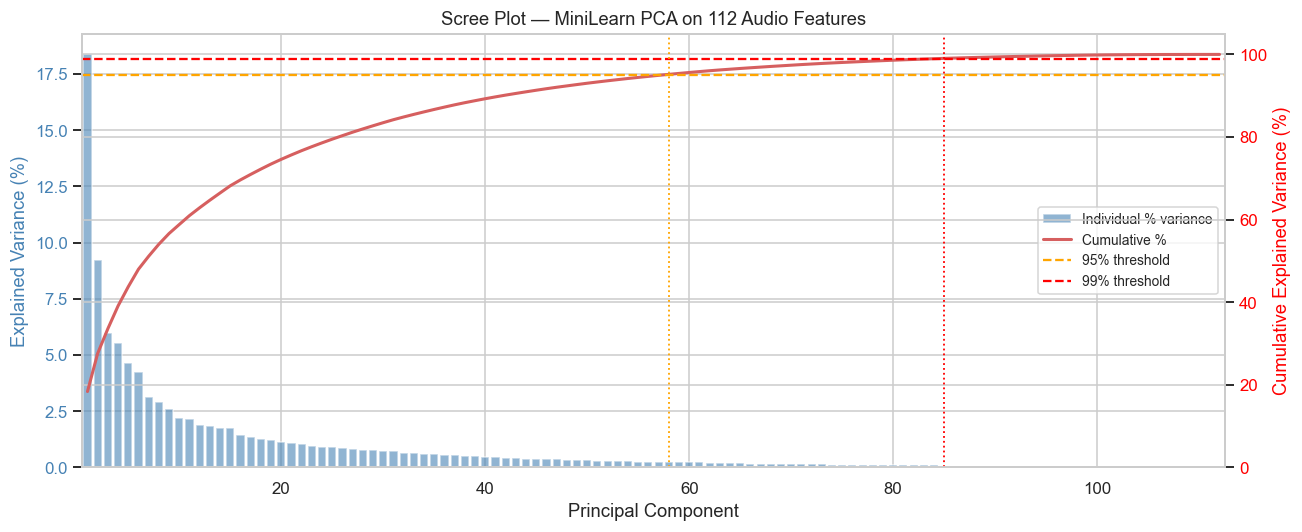

In [2]:
# Fit full PCA on training data (keep all 112 components)
pca_full = PCA(n_components=None)
pca_full.fit(X_train)

evr  = pca_full.explained_variance_ratio_
cumr = evr.cumsum()
n_features = len(evr)

# Find n_components for 95% and 99% thresholds
n95 = int(np.searchsorted(cumr, 0.95)) + 1
n99 = int(np.searchsorted(cumr, 0.99)) + 1
print(f'Components for ≥95% variance : {n95}  (out of {n_features})')
print(f'Components for ≥99% variance : {n99}')

# ── Scree plot ────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(range(1, n_features + 1), evr * 100, alpha=0.6,
        color='steelblue', label='Individual % variance')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xlim(0.5, n_features + 0.5)

ax2 = ax1.twinx()
ax2.plot(range(1, n_features + 1), cumr * 100, 'r-', linewidth=2,
         label='Cumulative %')
ax2.axhline(95, color='orange', linestyle='--', linewidth=1.5, label='95% threshold')
ax2.axhline(99, color='red',    linestyle='--', linewidth=1.5, label='99% threshold')
ax2.axvline(n95, color='orange', linestyle=':', linewidth=1.2)
ax2.axvline(n99, color='red',    linestyle=':', linewidth=1.2)
ax2.set_ylabel('Cumulative Explained Variance (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 105)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=9)

plt.title('Scree Plot — MiniLearn PCA on 112 Audio Features')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pca_scree_plot.png'), bbox_inches='tight')
plt.show()

## 2. Dimensionality Reduction for Classification

Reduced shape: (1956, 58)  (from 112 → 58 features, 95.2% variance retained)
Logistic Regression     full=0.6734  pca=0.5786  Δ=-0.0948
SVC (RBF)               full=0.6734  pca=0.6351  Δ=-0.0383
Random Forest           full=0.6028  pca=0.5726  Δ=-0.0302

                      Full Acc  PCA Acc   Δ Acc  Full Macro-F1  PCA Macro-F1
Model                                                                      
Logistic Regression    0.6734   0.5786 -0.0948         0.6693        0.5718
SVC (RBF)              0.6734   0.6351 -0.0383         0.6644        0.6292
Random Forest          0.6028   0.5726 -0.0302         0.5863        0.5401


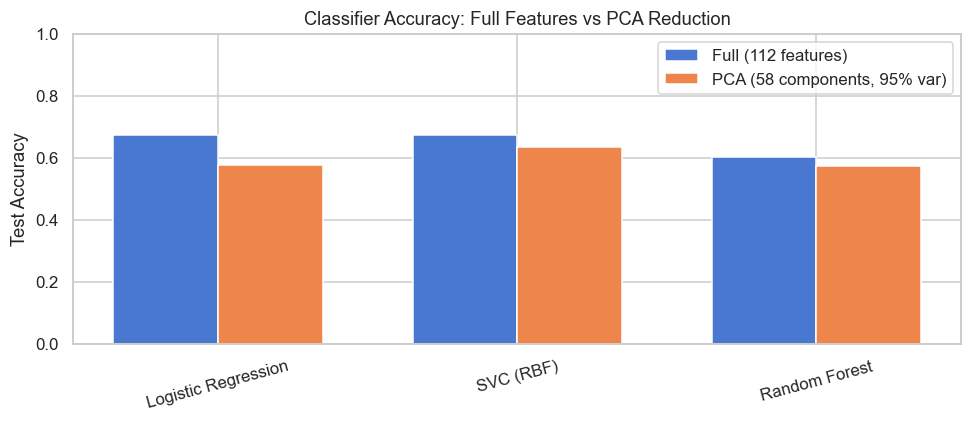

In [3]:
# Fit PCA retaining 95% variance — fit on train only
pca_95 = PCA(n_components=n95)
X_train_pca = pca_95.fit_transform(X_train)
X_test_pca  = pca_95.transform(X_test)

print(f'Reduced shape: {X_train_pca.shape}  '
      f'(from {X_train.shape[1]} → {n95} features, '
      f'{pca_95.explained_variance_ratio_.sum()*100:.1f}% variance retained)')

# ── Classifiers: full features vs PCA-reduced ────────────────────────────────
classifiers = {
    'Logistic Regression': SklearnLR(max_iter=1000, solver='lbfgs'),
    'SVC (RBF)':           SVC(kernel='rbf', gamma='scale'),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

rows = []
for name, clf in classifiers.items():
    # Full features
    clf.fit(X_train, y_train)
    acc_full = accuracy(y_test, clf.predict(X_test))
    f1_full  = f1_score(y_test, clf.predict(X_test), average='macro')

    # PCA-reduced features
    clf.fit(X_train_pca, y_train)
    acc_pca = accuracy(y_test, clf.predict(X_test_pca))
    f1_pca  = f1_score(y_test, clf.predict(X_test_pca), average='macro')

    rows.append({
        'Model':          name,
        'Full Acc':       round(acc_full, 4),
        'PCA Acc':        round(acc_pca,  4),
        'Δ Acc':          round(acc_pca - acc_full, 4),
        'Full Macro-F1':  round(f1_full,  4),
        'PCA Macro-F1':   round(f1_pca,   4),
    })
    print(f'{name:<22}  full={acc_full:.4f}  pca={acc_pca:.4f}  '
          f'Δ={acc_pca-acc_full:+.4f}')

comparison = pd.DataFrame(rows).set_index('Model')
print('\n', comparison.to_string())

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
x     = np.arange(len(comparison))
width = 0.35
ax.bar(x - width/2, comparison['Full Acc'], width, label=f'Full ({X_train.shape[1]} features)')
ax.bar(x + width/2, comparison['PCA Acc'],  width, label=f'PCA ({n95} components, 95% var)')
ax.set_xticks(x); ax.set_xticklabels(comparison.index, rotation=15)
ax.set_ylabel('Test Accuracy'); ax.set_ylim(0, 1)
ax.set_title('Classifier Accuracy: Full Features vs PCA Reduction')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pca_classifier_comparison.png'), bbox_inches='tight')
plt.show()

## 3. MiniLearn PCA vs sklearn PCA Comparison

Max |EVR difference| across 58 components : 1.39e-16


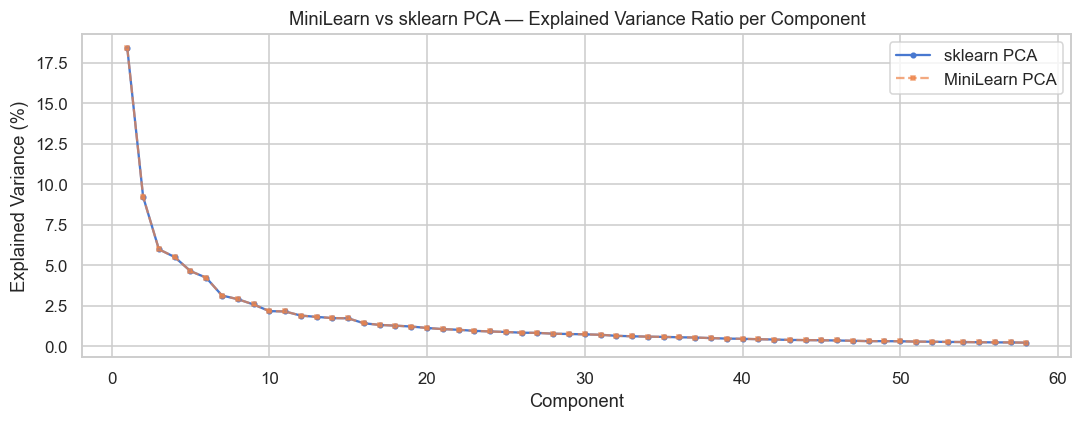

Cosine similarity (sign-aligned) — min: 1.000000  mean: 1.000000  max: 1.000000
→ Values near 1.0 confirm MiniLearn and sklearn find the same axes.


In [4]:
# Fit both implementations on training data
sk_pca = SklearnPCA(n_components=n95)
sk_pca.fit(X_train)

ml_pca = PCA(n_components=n95)
ml_pca.fit(X_train)

# ── Explained variance ratio comparison ───────────────────────────────────────
evr_diff = np.abs(ml_pca.explained_variance_ratio_ - sk_pca.explained_variance_ratio_)
print(f'Max |EVR difference| across {n95} components : {evr_diff.max():.2e}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, n95 + 1), sk_pca.explained_variance_ratio_ * 100,
        'o-', markersize=3, label='sklearn PCA')
ax.plot(range(1, n95 + 1), ml_pca.explained_variance_ratio_ * 100,
        's--', markersize=3, alpha=0.7, label='MiniLearn PCA')
ax.set_xlabel('Component'); ax.set_ylabel('Explained Variance (%)')
ax.set_title('MiniLearn vs sklearn PCA — Explained Variance Ratio per Component')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pca_minilearn_vs_sklearn.png'), bbox_inches='tight')
plt.show()

# ── Component sign alignment and cosine similarity ────────────────────────────
# Eigenvectors are unique only up to sign — align signs before comparing
ml_comps = ml_pca.components_.copy()
sk_comps = sk_pca.components_.copy()
for i in range(n95):
    if np.dot(ml_comps[i], sk_comps[i]) < 0:
        ml_comps[i] *= -1   # flip sign to match sklearn

cosine_sims = np.array([
    np.dot(ml_comps[i], sk_comps[i]) /
    (np.linalg.norm(ml_comps[i]) * np.linalg.norm(sk_comps[i]))
    for i in range(n95)
])
print(f'Cosine similarity (sign-aligned) — min: {cosine_sims.min():.6f}  '
      f'mean: {cosine_sims.mean():.6f}  max: {cosine_sims.max():.6f}')
print('→ Values near 1.0 confirm MiniLearn and sklearn find the same axes.')

## 4. 2D Visualization

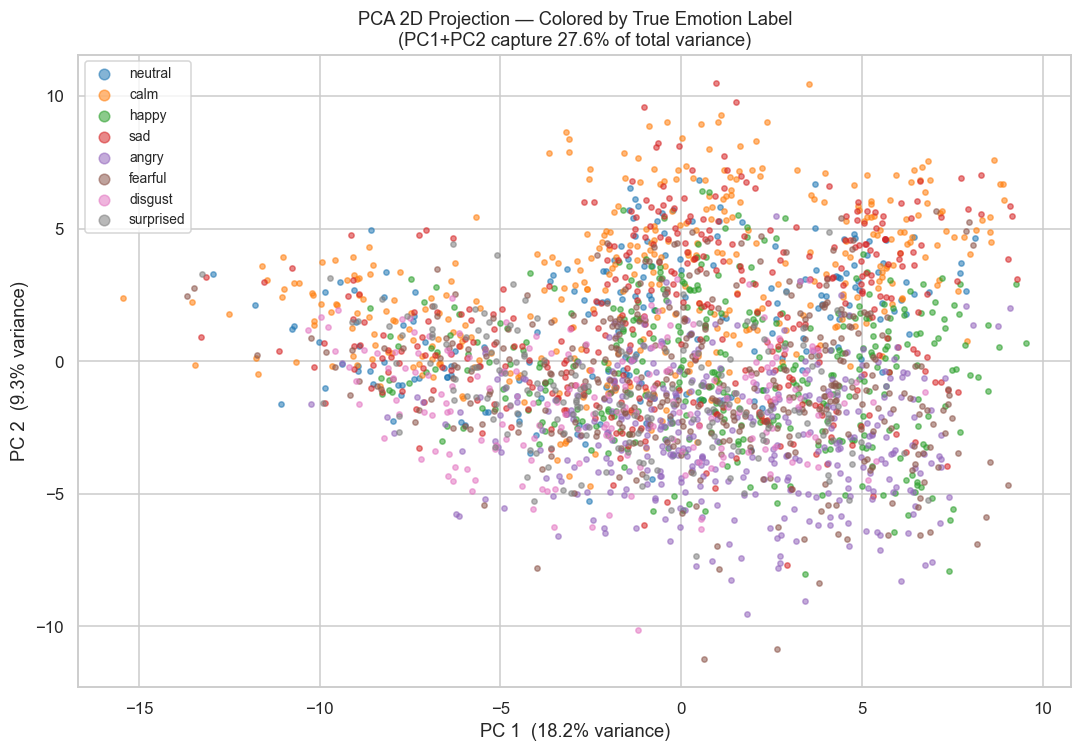

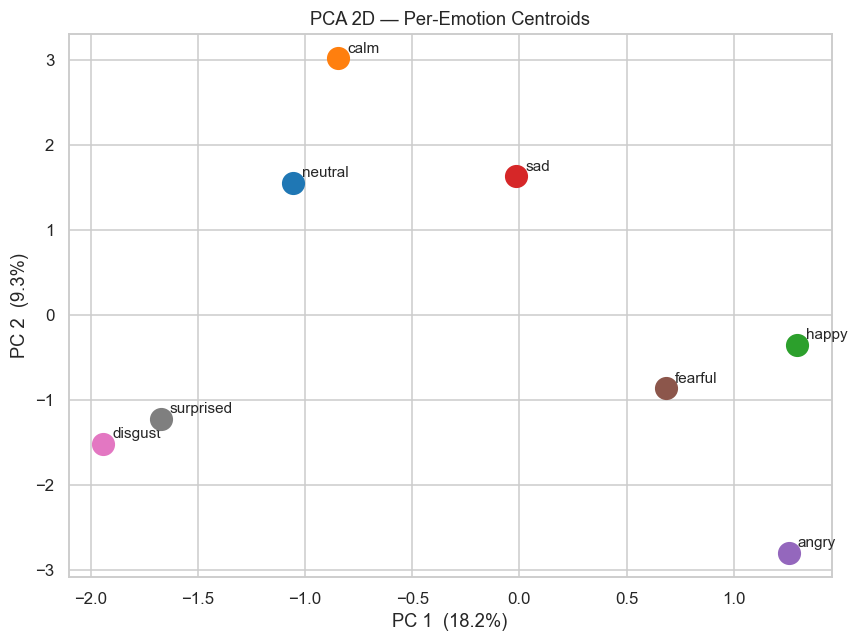

In [5]:
# Use all training + test data for a richer scatter
X_all = np.vstack([X_train, X_test])
y_all = np.concatenate([y_train, y_test])

pca_2d = PCA(n_components=2)
X_2d   = pca_2d.fit_transform(X_all)

var1 = pca_2d.explained_variance_ratio_[0] * 100
var2 = pca_2d.explained_variance_ratio_[1] * 100

palette  = sns.color_palette('tab10', 8)
emo_ids  = sorted(EMOTION_MAP)

fig, ax = plt.subplots(figsize=(10, 7))
for i, emo_id in enumerate(emo_ids):
    mask = y_all == emo_id
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               s=12, alpha=0.55, color=palette[i],
               label=EMOTION_MAP[emo_id])

ax.set_xlabel(f'PC 1  ({var1:.1f}% variance)')
ax.set_ylabel(f'PC 2  ({var2:.1f}% variance)')
ax.set_title('PCA 2D Projection — Colored by True Emotion Label\n'
             f'(PC1+PC2 capture {var1+var2:.1f}% of total variance)')
ax.legend(markerscale=2, fontsize=9, loc='best')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pca2d_emotion_scatter.png'), bbox_inches='tight')
plt.show()

# ── Per-emotion centroid plot (cleaner view of class separation) ──────────────
fig, ax = plt.subplots(figsize=(8, 6))
for i, emo_id in enumerate(emo_ids):
    mask    = y_all == emo_id
    centroid = X_2d[mask].mean(axis=0)
    ax.scatter(*centroid, s=200, color=palette[i], zorder=5)
    ax.annotate(EMOTION_MAP[emo_id], centroid,
                textcoords='offset points', xytext=(6, 4), fontsize=10)

ax.set_xlabel(f'PC 1  ({var1:.1f}%)')
ax.set_ylabel(f'PC 2  ({var2:.1f}%)')
ax.set_title('PCA 2D — Per-Emotion Centroids')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pca2d_emotion_centroids.png'), bbox_inches='tight')
plt.show()

## 5. Discussion

*Address:*
- *How many components are needed to retain 95% of variance?  Is this surprising?*
- *Does PCA compression hurt or help classifier accuracy?  Why?*
- *Are emotions visually separable in the 2D PCA projection?*